In [1]:
from pathlib import Path
import sys
import json

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

public_root = Path(config["public_root"])

print("Public root exists:", public_root.exists())
print(public_root)

Public root exists: True
C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI


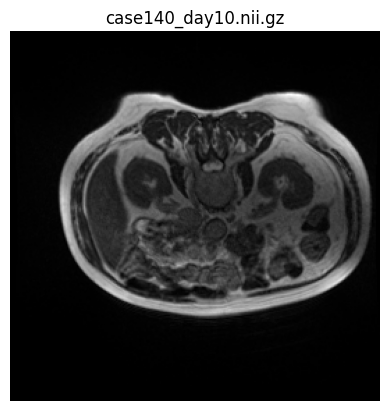

In [2]:
from src.eda.build_public_scan_inventory import find_nifti_files
import nibabel as nib
import matplotlib.pyplot as plt
import json
from pathlib import Path

config_path = project_root / "configs" / "datasets" / "public_dataset.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

public_root = Path(config["public_root"])
files = find_nifti_files(public_root)

scan_path = files[90]
data = nib.load(str(scan_path)).get_fdata()

slice_idx = data.shape[2] // 2
plt.imshow(data[:, :, slice_idx].T, cmap="gray", origin="lower")
plt.title(scan_path.name)
plt.axis("off")
plt.show()

In [3]:
from src.eda.visualize_masks import create_mask, show_overlay
import pandas as pd
import cv2

df = pd.read_csv("data/train.csv")

image_path = "data/train/...png"
image_id = "case123_day20_slice_0001"

image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
mask = create_mask(df, image_id, image.shape)

show_overlay(image, mask)

ModuleNotFoundError: No module named 'cv2'